In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
# Setting up and loading data
# Returns the Caloronia housing dataset
# Extracts feature and target variables from dataset
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

In [5]:
# Splitting Data for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling features for regularization methods Ridge, Lasso, and Elastic Net
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Defining a range of alphas for tuning. The logspace allows testing small and large spaces with equal prority.
# Using l1_ratios is for the Elastic Net model and also to help determing Lasson and Ridge penelaties
alphas = np.logspace(-4, 0, 100)
l1_ratios = np.arange(0.0, 1.0, 0.01)

In [10]:
# Model implementation and tuning with cross-validation & Ridge Regression (L2) with cross-validation
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

RidgeCV(alphas=array([1.00000000e-04, 1.09749877e-04, 1.20450354e-04, 1.32194115e-04,
       1.45082878e-04, 1.59228279e-04, 1.74752840e-04, 1.91791026e-04,
       2.10490414e-04, 2.31012970e-04, 2.53536449e-04, 2.78255940e-04,
       3.05385551e-04, 3.35160265e-04, 3.67837977e-04, 4.03701726e-04,
       4.43062146e-04, 4.86260158e-04, 5.33669923e-04, 5.85702082e-04,
       6.42807312e-04, 7.05480231e-0...
       1.17681195e-01, 1.29154967e-01, 1.41747416e-01, 1.55567614e-01,
       1.70735265e-01, 1.87381742e-01, 2.05651231e-01, 2.25701972e-01,
       2.47707636e-01, 2.71858824e-01, 2.98364724e-01, 3.27454916e-01,
       3.59381366e-01, 3.94420606e-01, 4.32876128e-01, 4.75081016e-01,
       5.21400829e-01, 5.72236766e-01, 6.28029144e-01, 6.89261210e-01,
       7.56463328e-01, 8.30217568e-01, 9.11162756e-01, 1.00000000e+00]),
        cv=5)

In [11]:
# Lasso Regression (L1) with cross-validation
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train)

LassoCV(alphas=array([1.00000000e-04, 1.09749877e-04, 1.20450354e-04, 1.32194115e-04,
       1.45082878e-04, 1.59228279e-04, 1.74752840e-04, 1.91791026e-04,
       2.10490414e-04, 2.31012970e-04, 2.53536449e-04, 2.78255940e-04,
       3.05385551e-04, 3.35160265e-04, 3.67837977e-04, 4.03701726e-04,
       4.43062146e-04, 4.86260158e-04, 5.33669923e-04, 5.85702082e-04,
       6.42807312e-04, 7.05480231e-0...
       1.17681195e-01, 1.29154967e-01, 1.41747416e-01, 1.55567614e-01,
       1.70735265e-01, 1.87381742e-01, 2.05651231e-01, 2.25701972e-01,
       2.47707636e-01, 2.71858824e-01, 2.98364724e-01, 3.27454916e-01,
       3.59381366e-01, 3.94420606e-01, 4.32876128e-01, 4.75081016e-01,
       5.21400829e-01, 5.72236766e-01, 6.28029144e-01, 6.89261210e-01,
       7.56463328e-01, 8.30217568e-01, 9.11162756e-01, 1.00000000e+00]),
        cv=5, n_jobs=-1, random_state=42)

In [12]:
# Elastic Net (L1 and L2) with cross-validation
elastic_net_cv = ElasticNetCV(alphas=alphas, l1_ratio=l1_ratios, cv=5, random_state=42, n_jobs=-1)
elastic_net_cv.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6537.72267102878, tolerance: 1.778593639468773
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent wit

ElasticNetCV(alphas=array([1.00000000e-04, 1.09749877e-04, 1.20450354e-04, 1.32194115e-04,
       1.45082878e-04, 1.59228279e-04, 1.74752840e-04, 1.91791026e-04,
       2.10490414e-04, 2.31012970e-04, 2.53536449e-04, 2.78255940e-04,
       3.05385551e-04, 3.35160265e-04, 3.67837977e-04, 4.03701726e-04,
       4.43062146e-04, 4.86260158e-04, 5.33669923e-04, 5.85702082e-04,
       6.42807312e-04, 7.054802...
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99]),
             n_jobs=-1, random_state=42)

In [17]:
# Evaluating the models

models = {
    'Ridge': ridge_cv,
    'Lasso': lasso_cv,
    'Elastic Net': elastic_net_cv
}

results = pd.DataFrame(columns=['Best Alpha', 'Best L1 Ratio', 'MSE', 'RMSE', 'R2 Score'])

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    if name == 'Ridge':
        best_alpha = model.alpha_
        best_l1_ratio = None
    elif name == 'Lasso':
        best_alpha = model.alpha_
        best_l1_ratio = None
    else:  # Elastic Net
        best_alpha = model.alpha_
        best_l1_ratio = model.l1_ratio_

    results.loc[name] = [best_alpha, best_l1_ratio, mse, rmse, r2]

print("Comparison of Regularization Methods")
print(results)

Comparison of Regularization Methods
             Best Alpha  Best L1 Ratio       MSE      RMSE  R2 Score
Ridge          0.000100            NaN  0.555892  0.745581  0.575788
Lasso          0.000643            NaN  0.554975  0.744967  0.576487
Elastic Net    0.000643           0.99  0.554981  0.744970  0.576483


We observe from these results that Lasso Regression is the best-performing model. These were the lowest values found: Mean Squared Error (MSE) of 0.554975, a Root Mean Squared Error (RMSE) of 0.744967, and an R² Score of 0.576487. These values are the most favorable among the three models, indicating the highest prediction accuracy.

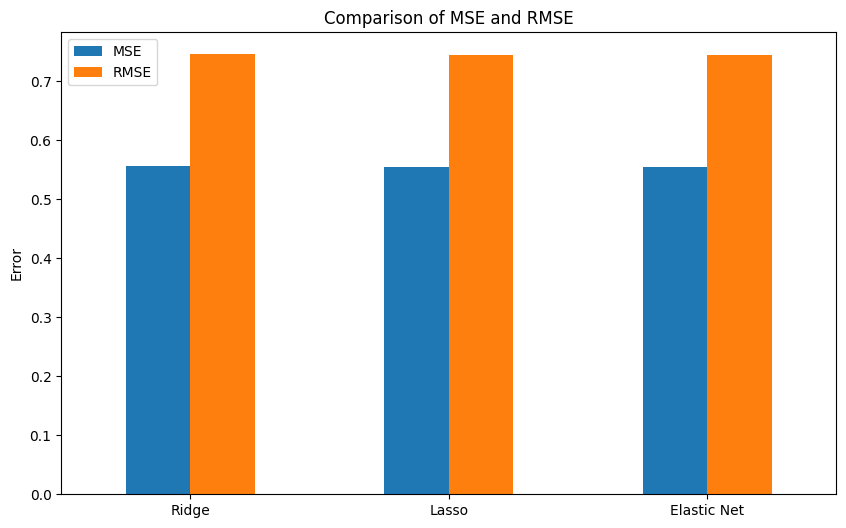

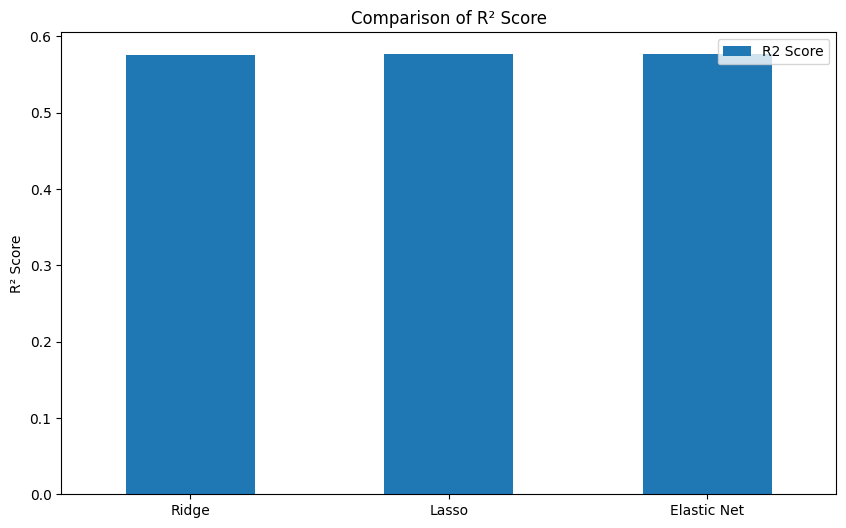

In [18]:
# Comparaing and visualizing the results

results[['MSE', 'RMSE']].plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Comparison of MSE and RMSE')
plt.ylabel('Error')
plt.show()

results[['R2 Score']].plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Comparison of R² Score')
plt.ylabel('R² Score')
plt.show()

The above are bar charts visually represent the performance of the three regularization models: Ridge, Lasso, and Elastic Net, based on three evaluation metrics: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. We can see that the three regularization methods perfrom similary, with slight differences. The actual detials we reviewed from the numners show that Lasson and Elastic Net models have an advantage over Ridge model.


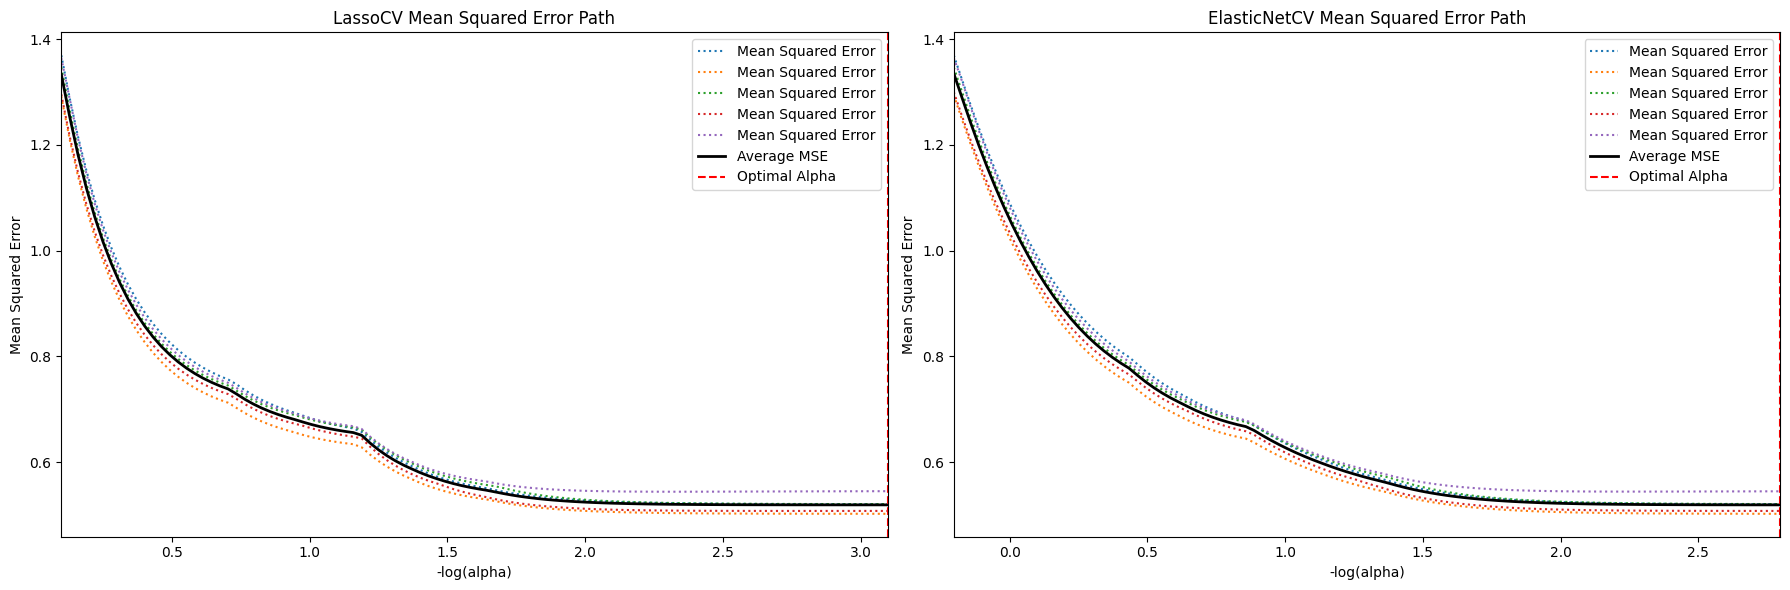

In [20]:
# Visualizing  regularization path
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Lasso Path
lcv = LassoCV(cv=5).fit(X_train_scaled, y_train)
m_log_alphas = -np.log10(lcv.alphas_)
ax1.plot(m_log_alphas, lcv.mse_path_, linestyle=':', label='Mean Squared Error')
ax1.plot(m_log_alphas, lcv.mse_path_.mean(axis=1), color='black', linewidth=2, label='Average MSE')
ax1.axvline(-np.log10(lcv.alpha_), linestyle='--', color='red', label='Optimal Alpha')
ax1.set_xlabel('-log(alpha)')
ax1.set_ylabel('Mean Squared Error')
ax1.set_title('LassoCV Mean Squared Error Path')
ax1.legend()
ax1.set_xbound(lower=m_log_alphas.min(), upper=m_log_alphas.max())

# ElasticNet Path
ecv = ElasticNetCV(cv=5).fit(X_train_scaled, y_train)
m_log_alphas = -np.log10(ecv.alphas_)
ax2.plot(m_log_alphas, ecv.mse_path_, linestyle=':', label='Mean Squared Error')
ax2.plot(m_log_alphas, ecv.mse_path_.mean(axis=1), color='black', linewidth=2, label='Average MSE')
ax2.axvline(-np.log10(ecv.alpha_), linestyle='--', color='red', label='Optimal Alpha')
ax2.set_xlabel('-log(alpha)')
ax2.set_ylabel('Mean Squared Error')
ax2.set_title('ElasticNetCV Mean Squared Error Path')
ax2.legend()
ax2.set_xbound(lower=m_log_alphas.min(), upper=m_log_alphas.max())

plt.tight_layout()
plt.show()

Based on the plots:

The graphs show that the best-performing models have a low regularization strength (alpha), which is represented by a high -log(alpha) value. Both models' errors (MSE) decrease rapidly at first and then level off around a -log(alpha) value of 1.0 to 1.5, where the MSE is at its lowest. Both models effectively select features and shrink coefficients towards zero, which is a key characteristic of L1 regularization.

Visually, the performance of the Lasso and Elastic Net models is nearly identical, indicating that both methods are similarly effective for this dataset.

 The concept of a** bias-variance trade-off** is seen here . First, with a high alpha (low -log(alpha)), the model is too simple (high bias) and the error is high. As alpha decreases, the model becomes more complex, the MSE drops, and the model strikes a better balance between bias and variance, reaching its minimum error at the optimal alpha value.



